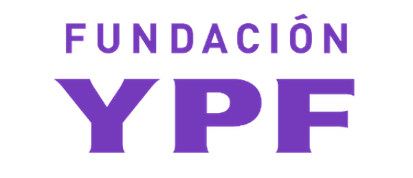

# Fundación YPF - Data Science

# Notebook 14: Fundamentos del Machine Learning

Esta notebook acompaña la clase 10. Recorre los cuatro conceptos de la parte teórica sobre datos reales: la tarea, la experiencia, el algoritmo y el aprendizaje.

## Índice

**Parte 0.** Repaso del módulo III: carga, faltantes, encoding y escalado

**Parte 1.** La tarea: qué queremos predecir

**Parte 2.** La experiencia: los datos con los que se aprende

**Parte 3.** El algoritmo: entrenar el primer modelo

**Parte 4.** El aprendizaje: medir si el modelo mejora con la experiencia

**Parte 5.** Ejercicio para las salas de Zoom

**Anexo.** Soluciones sugeridas de la Parte 5

## Datasets

`StudentsPerformance.csv` (partes 0 a 4) y `clientes_mall.csv` (parte 5). Los dos ya se usan en el curso.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, learning_curve
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

np.random.seed(42)
pd.set_option('display.max_columns', None)

In [6]:
def cargar(nombre):
    """Busca el archivo en /content/ (Colab) y, si no está, en el directorio local."""
    try:
        return pd.read_csv('/content/' + nombre)
    except FileNotFoundError:
        return pd.read_csv(nombre)

students = cargar('./NOTEBOOKS 2026/StudentsPerformance.csv')
students.head()

,Unnamed: 0,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,0,female,group B,bachelor's degree,standard,none,7.2,72,74
1,1,female,group C,some college,standard,completed,6.9,90,88
2,2,female,group B,master's degree,standard,none,9.0,95,93
3,3,male,group A,associate's degree,free/reduced,none,4.7,57,44
4,4,male,group C,some college,standard,none,7.6,78,75


## Parte 0. Repaso del módulo III

Antes de entrar en Machine Learning repasamos rápido lo que venimos haciendo desde la clase 5: mirar el dataset, resolver los faltantes, convertir las categorías en números y dejar las variables en una escala comparable.

Este preprocesamiento no es un trámite previo. Es la condición para que después haya algo que aprender.

In [ ]:
# Estructura general
print(students.shape)
students.info()

In [ ]:
# Columna de índice que quedó de la exportación
if 'Unnamed: 0' in students.columns:
    students = students.drop(columns=['Unnamed: 0'])

# Nombres de columnas más cómodos de escribir
students.columns = (students.columns
                    .str.strip()
                    .str.lower()
                    .str.replace(' ', '_')
                    .str.replace('/', '_'))
students.columns.tolist()

In [ ]:
# Faltantes
students.isna().sum()

In [ ]:
# Estadísticos de las tres notas
students[['math_score', 'reading_score', 'writing_score']].describe()

Atención a las escalas: en el archivo del curso `math_score` está en otro rango que `reading_score` y `writing_score`. Es exactamente el caso que motivó el escalado en la clase 8.

In [ ]:
# Encoding de las variables categóricas (clase 7)
categoricas = ['gender', 'race_ethnicity', 'parental_level_of_education',
               'lunch', 'test_preparation_course']

students_enc = pd.get_dummies(students, columns=categoricas, drop_first=True)
print('Antes:', students.shape, ' Después:', students_enc.shape)
students_enc.head(3)

## Parte 1. La tarea

En la teoría dijimos que la tarea está asociada a una función objetivo desconocida. En la práctica, definir la tarea es responder tres preguntas:

1. ¿Qué queremos predecir?
2. ¿Es una categoría o un número?
3. ¿Para qué serviría esa predicción?

Para esta notebook la tarea es: **predecir si una estudiante va a aprobar el examen de lectura**, usando el resto de la información disponible sobre ella.

La respuesta es una categoría (aprueba o no aprueba), así que estamos frente a un problema de **clasificación**. Si en cambio quisiéramos predecir el puntaje exacto, sería un problema de **regresión**.

In [ ]:
# Construimos la variable objetivo: aprueba si saca 60 o más en lectura
UMBRAL = 60
students_enc['aprueba_lectura'] = (students_enc['reading_score'] >= UMBRAL).astype(int)

students_enc['aprueba_lectura'].value_counts()

In [ ]:
proporcion = students_enc['aprueba_lectura'].mean()
print(f'Aprueban el {proporcion:.1%} de las estudiantes')
print(f'No aprueban el {1 - proporcion:.1%}')

Este número importa más de lo que parece. Si el 70% aprueba, un modelo que diga siempre "aprueba" acierta el 70% de las veces sin haber aprendido nada. Cualquier modelo que entrenemos tiene que superar ese piso para que valga la pena. Lo vamos a verificar en la Parte 4.

## Parte 2. La experiencia

La experiencia son los datos de los que el algoritmo aprende. En la práctica se separa en dos objetos:

- `X`: las variables de entrada, lo que el modelo puede mirar.
- `y`: la variable objetivo, la respuesta que queremos que aprenda a dar.

Hay una decisión importante acá. `reading_score` **no puede quedar en X**: la variable objetivo se calculó a partir de ella, así que el modelo tendría la respuesta servida y el resultado no significaría nada. Este error tiene nombre propio: fuga de información, o *data leakage*.

In [ ]:
# La variable objetivo y todo lo que se derive de ella salen de X
X = students_enc.drop(columns=['aprueba_lectura', 'reading_score'])
y = students_enc['aprueba_lectura']

print('Variables de entrada:', X.shape[1])
X.columns.tolist()

### Separar entrenamiento y test

Un modelo que responde bien sobre los mismos datos con los que aprendió no demuestra nada: puede simplemente haberlos memorizado. Para saber si aprendió de verdad hay que evaluarlo sobre datos que nunca vio.

Por eso separamos antes de entrenar. Es el mismo criterio que vimos en la clase 8 para ajustar los escaladores.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y      # mantiene la misma proporción de aprobadas en ambos conjuntos
)

print(f'Entrenamiento: {X_train.shape[0]} estudiantes')
print(f'Test:          {X_test.shape[0]} estudiantes')
print(f'Proporción que aprueba en train: {y_train.mean():.1%}')
print(f'Proporción que aprueba en test:  {y_test.mean():.1%}')

In [ ]:
# El escalador se ajusta SOLO con los datos de entrenamiento (clase 8)
scaler = StandardScaler()
X_train_esc = scaler.fit_transform(X_train)
X_test_esc = scaler.transform(X_test)   # transform, no fit_transform

print('Media aprendida de las primeras 3 columnas:', scaler.mean_[:3].round(2))

## Parte 3. El algoritmo

El algoritmo es el procedimiento que busca, entre todos los modelos posibles, el que mejor se ajusta a los datos. El modelo es el resultado de esa búsqueda.

Vamos a usar un **árbol de decisión**, que tiene la ventaja de que se puede dibujar y leer. El árbol va partiendo los datos con preguntas del tipo "¿el puntaje de escritura es mayor a 65?" y arma un camino de decisiones hasta llegar a una respuesta.

En scikit-learn todos los algoritmos siguen el mismo patrón de tres pasos: se crea el modelo, se lo entrena con `.fit()` y se predice con `.predict()`.

In [ ]:
# 1. Crear el modelo
arbol = DecisionTreeClassifier(max_depth=3, random_state=42)

# 2. Entrenar: acá ocurre el aprendizaje
arbol.fit(X_train, y_train)

# 3. Predecir sobre datos que el modelo no vio
y_pred = arbol.predict(X_test)

y_pred[:20]

In [ ]:
fig, ax = plt.subplots(figsize=(18, 8))
plot_tree(arbol,
          feature_names=X.columns,
          class_names=['No aprueba', 'Aprueba'],
          filled=True, rounded=True, fontsize=9, ax=ax)
ax.set_title('El modelo entrenado: árbol de decisión con profundidad 3')
plt.tight_layout()
plt.show()

Cada caja del árbol es una pregunta. Se lee de arriba hacia abajo: si la respuesta es verdadera se sigue por la rama izquierda, si es falsa por la derecha. Las cajas del final dan la predicción.

Este dibujo es el modelo. El algoritmo fue el procedimiento que decidió qué preguntas hacer y en qué orden.

In [ ]:
# Qué variables terminó usando el árbol
importancias = (pd.Series(arbol.feature_importances_, index=X.columns)
                .sort_values(ascending=False)
                .head(8))

fig, ax = plt.subplots(figsize=(9, 4))
importancias.sort_values().plot.barh(ax=ax, color='#753ABC')
ax.set_xlabel('Importancia')
ax.set_title('Variables en las que se apoyó el modelo')
plt.tight_layout()
plt.show()

## Parte 4. El aprendizaje

La definición de la clase fue: **un algoritmo aprende una tarea si su rendimiento mejora con la experiencia**. Vamos a verificar las dos mitades de esa frase.

Primero el rendimiento: cuánto acierta el modelo sobre datos que no vio.

In [ ]:
exactitud = accuracy_score(y_test, y_pred)
print(f'Exactitud del árbol en test: {exactitud:.1%}')

In [ ]:
# El piso a superar: un modelo que responde siempre la clase más frecuente
tonto = DummyClassifier(strategy='most_frequent', random_state=42)
tonto.fit(X_train, y_train)
exactitud_tonto = accuracy_score(y_test, tonto.predict(X_test))

print(f'Modelo sin aprendizaje (siempre la clase más frecuente): {exactitud_tonto:.1%}')
print(f'Árbol de decisión:                                       {exactitud:.1%}')
print(f'Diferencia:                                              {exactitud - exactitud_tonto:+.1%}')

Si la diferencia fuera cero o negativa, el modelo no estaría aportando nada. Comparar siempre contra un piso es una costumbre que conviene tomar desde ahora.

In [ ]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred),
    display_labels=['No aprueba', 'Aprueba']
).plot(ax=ax, cmap='Purples', colorbar=False)
ax.set_title('Dónde acierta y dónde se equivoca')
plt.tight_layout()
plt.show()

### ¿El rendimiento mejora con la experiencia?

Esta es la otra mitad de la definición. Entrenamos el mismo algoritmo con cantidades crecientes de datos y vemos qué pasa con el rendimiento.

In [ ]:
tamanos, score_train, score_test = learning_curve(
    DecisionTreeClassifier(max_depth=3, random_state=42),
    X, y,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5,
    random_state=42
)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(tamanos, score_test.mean(axis=1), 'o-', color='#753ABC',
        label='Rendimiento sobre datos nuevos')
ax.plot(tamanos, score_train.mean(axis=1), 'o--', color='#3AAFA9',
        label='Rendimiento sobre los datos de entrenamiento')
ax.set_xlabel('Cantidad de ejemplos usados para entrenar (experiencia)')
ax.set_ylabel('Exactitud')
ax.set_title('El rendimiento mejora a medida que aumenta la experiencia')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

La curva violeta es la definición de aprendizaje hecha gráfico: con pocos ejemplos el modelo rinde mal, y a medida que sumamos experiencia el rendimiento sube y después se estabiliza.

Ese amesetamiento también dice algo útil: a partir de cierto punto, sumar datos deja de ser la palanca más efectiva y conviene cambiar de algoritmo o de variables.

In [ ]:
# Cómo cambia el rendimiento según la profundidad del árbol
resultados = []
for prof in range(1, 15):
    m = DecisionTreeClassifier(max_depth=prof, random_state=42)
    m.fit(X_train, y_train)
    resultados.append({
        'profundidad': prof,
        'train': accuracy_score(y_train, m.predict(X_train)),
        'test': accuracy_score(y_test, m.predict(X_test))
    })

resultados = pd.DataFrame(resultados)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(resultados['profundidad'], resultados['test'], 'o-', color='#753ABC',
        label='Datos nuevos (test)')
ax.plot(resultados['profundidad'], resultados['train'], 'o--', color='#3AAFA9',
        label='Datos de entrenamiento')
ax.set_xlabel('Profundidad máxima del árbol')
ax.set_ylabel('Exactitud')
ax.set_title('Más complejidad no es más aprendizaje')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

resultados

Acá aparece algo que se va a trabajar en detalle más adelante en el curso: el rendimiento sobre los datos de entrenamiento sube casi hasta el 100%, pero el rendimiento sobre datos nuevos deja de mejorar y empieza a caer.

El modelo dejó de aprender la tarea y pasó a memorizar los ejemplos. Por ahora alcanza con registrar el fenómeno y quedarse con la conclusión práctica: el rendimiento que importa es siempre el que se mide sobre datos que el modelo no vio.

## Parte 5. Ejercicio para las salas de Zoom

Trabajamos con `clientes_mall.csv`, un dataset de clientes de un shopping con su edad, su ingreso anual y un puntaje de gasto asignado por el comercio.

**Objetivo:** predecir si un cliente es de gasto alto, usando el resto de la información.

Tiempo sugerido: 40 minutos. Cada paso tiene su celda de trabajo vacía.

In [7]:
clientes = cargar('./NOTEBOOKS 2026/clientes_mall.csv')
clientes.head()

,Unnamed: 0,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,0,1.0,Male,19.0,15.0,39.0
1,1,2.0,NaN,21.0,15.0,81.0
2,2,3.0,Female,20.0,16.0,6.0
3,3,4.0,Female,23.0,16.0,77.0
4,4,5.0,NaN,31.0,17.0,40.0


### Paso 1. Preparar los datos (10 minutos)

Repetí sobre este dataset lo que hicimos en la Parte 0:

- sacá la columna de índice sobrante, si la hay
- normalizá los nombres de las columnas
- revisá los faltantes y decidí qué hacer con ellos
- convertí la columna de género en numérica

Pista: `Genre` tiene valores faltantes. Pensá si conviene imputarlos o descartar esas filas, y justificá la decisión.

In [8]:
# Columna de índice que quedó de la exportación
if 'Unnamed: 0' in clientes.columns:
    clientes = clientes.drop(columns=['Unnamed: 0'])

# Nombres de columnas más cómodos de escribir
clientes.columns = (clientes.columns
                    .str.strip()
                    .str.lower()
                    .str.replace(' ', '_')
                    .str.replace('/', '_'))
clientes.columns.tolist()


['customerid', 'genre', 'age', 'annual_income_(k$)', 'spending_score_(1-100)']

### Paso 2. Definir la tarea y la experiencia (10 minutos)

- Escribí en una celda de texto, en una sola frase, cuál es la tarea.
- Creá la variable objetivo `gasto_alto`, que valga 1 cuando el puntaje de gasto sea mayor a 50.
- Armá `X` e `y`. Cuidado con la fuga de información: pensá qué columnas no pueden quedar en `X`.
- Separá en entrenamiento y test con `stratify`.

In [ ]:
# Tu código acá


### Paso 3. Entrenar y medir (10 minutos)

- Entrená un `DecisionTreeClassifier` con `max_depth=3`.
- Medí la exactitud sobre test.
- Compará contra un `DummyClassifier`. ¿El modelo aporta algo?

In [ ]:
# Tu código acá


### Paso 4. Explorar la profundidad (10 minutos)

Probá con `max_depth` igual a 1, 3, 5 y 10, y anotá qué pasa con la exactitud en entrenamiento y en test.

Preguntas para la puesta en común:

1. ¿Qué profundidad da el mejor rendimiento sobre datos nuevos?
2. ¿A partir de qué punto el modelo empieza a memorizar en vez de aprender?
3. ¿Qué variable resultó más importante? ¿Tiene sentido con lo que sabés del negocio?

In [ ]:
# Tu código acá


### Errores frecuentes a evitar

- Dejar en `X` la columna con la que se construyó `y`. El modelo acierta casi todo y el resultado no significa nada.
- Medir el rendimiento sobre los datos de entrenamiento y presentarlo como si fuera el rendimiento del modelo.
- Ajustar el escalador con el dataset completo en lugar de solamente con el conjunto de entrenamiento.
- Informar una exactitud alta sin compararla contra el piso del `DummyClassifier`.

## Anexo. Soluciones sugeridas de la Parte 5

Para entregar una versión sin soluciones, se borra esta última sección.

In [ ]:
# Paso 1. Preparar los datos
clientes = cargar('clientes_mall.csv')

if 'Unnamed: 0' in clientes.columns:
    clientes = clientes.drop(columns=['Unnamed: 0'])

clientes.columns = (clientes.columns
                    .str.strip()
                    .str.lower()
                    .str.replace(' ', '_')
                    .str.replace('(', '', regex=False)
                    .str.replace(')', '', regex=False))

print(clientes.isna().sum())
print()

# Genre tiene faltantes. Con 200 filas conviene imputar antes que descartar:
# usamos la moda, que es la estrategia habitual para una categórica.
clientes['genre'] = clientes['genre'].fillna(clientes['genre'].mode()[0])
clientes = clientes.dropna()

clientes['genre_male'] = (clientes['genre'] == 'Male').astype(int)
print(clientes.shape)
clientes.head()

In [ ]:
# Paso 2. Tarea y experiencia
# Tarea: predecir si un cliente del shopping es de gasto alto,
# a partir de su edad, su ingreso anual y su género.

col_gasto = [c for c in clientes.columns if 'spending' in c][0]
clientes['gasto_alto'] = (clientes[col_gasto] > 50).astype(int)

# customerid es un identificador, no aporta información
# col_gasto sale de X porque de ahí se construyó y
Xc = clientes.drop(columns=['gasto_alto', col_gasto, 'genre', 'customerid'])
yc = clientes['gasto_alto']

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    Xc, yc, test_size=0.25, random_state=42, stratify=yc)

print('Variables:', Xc.columns.tolist())
print(f'Train: {Xc_train.shape[0]}  Test: {Xc_test.shape[0]}')
print(f'Proporción de gasto alto: {yc.mean():.1%}')

In [ ]:
# Paso 3. Entrenar y medir
arbol_c = DecisionTreeClassifier(max_depth=3, random_state=42)
arbol_c.fit(Xc_train, yc_train)

acc = accuracy_score(yc_test, arbol_c.predict(Xc_test))

dummy_c = DummyClassifier(strategy='most_frequent', random_state=42)
dummy_c.fit(Xc_train, yc_train)
acc_dummy = accuracy_score(yc_test, dummy_c.predict(Xc_test))

print(f'Árbol:  {acc:.1%}')
print(f'Piso:   {acc_dummy:.1%}')
print(f'Aporte: {acc - acc_dummy:+.1%}')

In [ ]:
# Paso 4. Explorar la profundidad
filas = []
for prof in [1, 3, 5, 10]:
    m = DecisionTreeClassifier(max_depth=prof, random_state=42)
    m.fit(Xc_train, yc_train)
    filas.append({
        'profundidad': prof,
        'train': round(accuracy_score(yc_train, m.predict(Xc_train)), 3),
        'test': round(accuracy_score(yc_test, m.predict(Xc_test)), 3)
    })

print(pd.DataFrame(filas).to_string(index=False))
print()

importancias_c = pd.Series(arbol_c.feature_importances_, index=Xc.columns)
print('Importancia de cada variable:')
print(importancias_c.sort_values(ascending=False).round(3).to_string())

### Comentario sobre el resultado

El árbol supera al piso por unos quince puntos, así que sí aprendió algo. Pero la tabla de profundidades muestra el fenómeno completo: al pasar de profundidad 1 a 10, la exactitud en entrenamiento trepa del 69% al 98%, mientras que la exactitud sobre datos nuevos se queda estancada alrededor del 70%.

Ese es el punto de la clase. El modelo profundo no aprendió mejor la tarea, memorizó los ejemplos que vio. Y como el rendimiento que importa es el que se mide sobre datos nuevos, el árbol de profundidad 1 es tan bueno como el de profundidad 10, con la ventaja de que se entiende de un vistazo.

La importancia de las variables agrega otra lectura: casi toda la decisión se apoya en la edad, el ingreso aporta poco y el género no aporta nada. Cuando las variables disponibles no contienen la información necesaria, ningún algoritmo la inventa. La experiencia tiene que ser la adecuada para la tarea, no solamente abundante.

Este mismo dataset se retoma en el módulo de aprendizaje no supervisado, donde la pregunta cambia: en vez de predecir el gasto, vamos a buscar grupos naturales de clientes.